# 패키지 및 데이터

In [71]:
# ==================================================
# 기본 라이브러리
# ==================================================
import numpy as np
import seaborn as sb

from matplotlib import pyplot as plt
from pandas import DataFrame, concat


# ==================================================
# scikit-learn 공통
# ==================================================
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    learning_curve,
)

from sklearn.preprocessing import StandardScaler


# ==================================================
# 분류 모델
# ==================================================
from sklearn.linear_model import (
    LogisticRegression,
    SGDClassifier,
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    log_loss,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
)

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)


# ==================================================
# Boosting 계열
# ==================================================
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# ==================================================
# 사용자 정의 모듈
# ==================================================
from hossam import *


### 데이터

In [72]:
origin = load_data("pima_indians_diabetes_preprocessed")
origin.head()
origin.info()

캐글에서 제공하는 pima_indians_diabetes의 전처리 완료 버전(결측치 정제+로그변환) (출처: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    float64
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    float64
 8   Outcome                   768 non-null    int64  
dtypes: float64(7), int64(2)
memory usage: 54.1 KB


# 훈련, 검증 데이터 분리

In [44]:
df = origin.copy()

df["Outcome"] = df["Outcome"].astype('int')

yname = "Outcome"
X = df.drop(columns=[yname])
y = df[yname]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 52)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((614, 8), (154, 8), (614,), (154,))

### 함수 정의

In [58]:
def hs_cls_bin_scores(estimator, X_test, y_test):
    # ===============================
    # 예측값 / 확률
    # ===============================
    y_pred_proba = estimator.predict_proba(X_test)[:, 1]
    y_pred = estimator.predict(X_test)

    # ===============================
    # McFadden pseudo R²
    # ===============================
    log_loss_test = -log_loss(y_test, y_pred_proba, normalize=False)

    y_null = np.ones_like(y_test) * (y_test.mean())
    log_loss_null = -log_loss(y_test, y_null, normalize=False)

    pseudo_r2 = 1 - (log_loss_test / log_loss_null)

    # ===============================
    # 혼동행렬
    # ===============================
    cm = confusion_matrix(y_test, y_pred)
    ((TN,FP), (FN, TP)) = cm

    # ===============================
    # 모델 클래스명
    # ===============================
    if hasattr(estimator, "named_steps"):
        class_name = estimator.named_steps["model"].__class__.__name__
    else:
        class_name = estimator.__class__.__name__

    # ===============================
    # AUC
    # ===============================
    auc_score = roc_auc_score(y_test, y_pred_proba)

    # ===============================
    # 성능 지표 DataFrame
    # ===============================
    score_df = DataFrame(
        {
            "의사결정계수(R2)": [pseudo_r2],
            "정확도(Accuracy)": [accuracy_score(y_test, y_pred)],
            "정밀도(Precision)": [precision_score(y_test, y_pred)],
            "재현율(Recall, TPR)": [recall_score(y_test, y_pred)],
            "위양성률(Fallout, FPR)": [FP / (TN + FP)],
            "특이성(TNR)": [TN / (TN + FP)],
            "F1 Score": [f1_score(y_test, y_pred)],
            "AUC": [auc_score],
        },
        index=[class_name],
    )

    # ===============================
    # ROC Curve
    # ===============================
    roc_fpr, roc_tpr, thresholds = roc_curve(y_test, y_pred_proba)

    my_dpi = 100
    width_px, height_px = 1000, 900
    rows, cols = 1, 1

    figsize = (width_px / my_dpi, height_px / my_dpi)
    fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

    sb.lineplot(x=roc_fpr, y=roc_tpr, ax=ax, label="ROC Curve")
    sb.lineplot(
        x=[0, 1],
        y=[0, 1],
        color="red",
        linestyle="--",
        alpha=0.5,
        ax=ax,
        label="Random",
    )

    ax.fill_between(roc_fpr, roc_tpr, alpha=0.1)

    ax.grid(True, alpha=0.3)
    ax.set_title(f"AUC = {auc_score:.4f}", fontsize=10, pad=4)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

    plt.tight_layout()
    plt.show()
    plt.close()

    return score_df


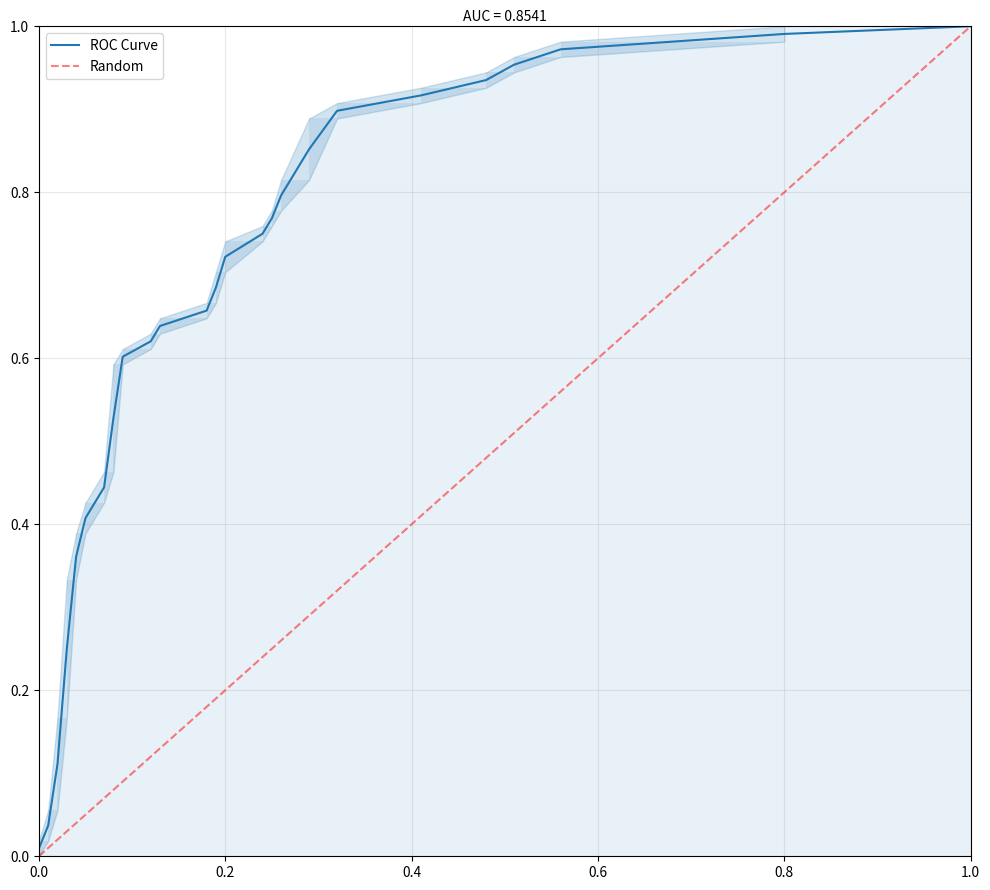

,의사결정계수(R2),정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성률(Fallout, FPR)",특이성(TNR),F1 Score,AUC
LogisticRegression,0.226,0.766,0.629,0.815,0.260,0.740,0.710,0.854


In [59]:
hs_cls_bin_scores(estimator, X_test, y_test)

# 로지스틱 회귀 모형

In [16]:
%%time

pipe = Pipeline([
    ("VIF_Selector", VIFSelector()),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=52))
])

param_grid = {
     "model__penalty": ["l2"],
    "model__solver": ["lbfgs"],
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__max_iter": [100, 300, 500],
    "model__class_weight": [None, "balanced"],
}

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=1
)

gs.fit(X_train, y_train)

estimator = gs.best_estimator_
estimator


CPU times: total: 1.2 s
Wall time: 1.22 s


Pipeline(steps=[('VIF_Selector', VIFSelector()), ('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=1, class_weight='balanced',
                                    random_state=52))])

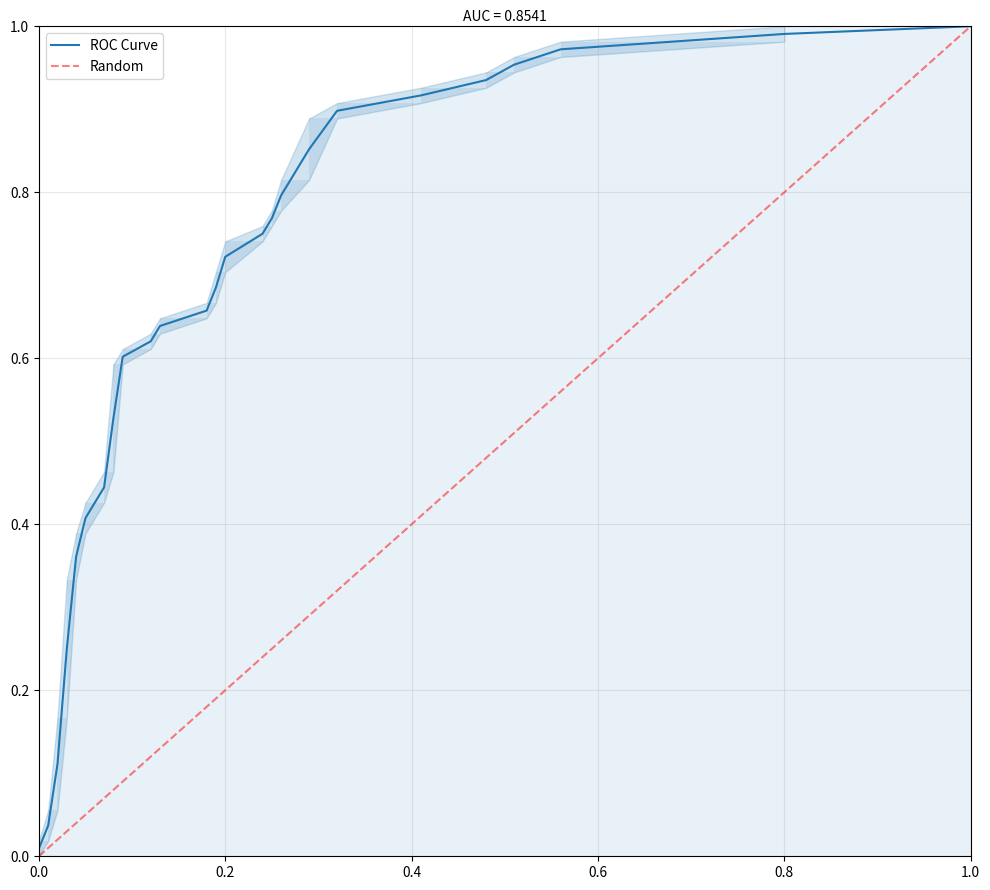

CPU times: total: 547 ms
Wall time: 5.85 s


,의사결정계수(R2),정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성률(Fallout, FPR)",특이성(TNR),F1 Score,AUC
LogisticRegression,0.226,0.766,0.629,0.815,0.260,0.740,0.710,0.854


In [17]:
%%time

# ==================================================
# 1. Pipeline 정의
# ==================================================
logit_pipe = Pipeline(
    steps=[
        ("vif_selector", VIFSelector()),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(random_state=52)),
    ]
)


# ==================================================
# 2. 하이퍼파라미터 설정
# ==================================================
logit_param_grid = {
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"],
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__max_iter": [100, 300, 500],
    "model__class_weight": [None, "balanced"],
}


# ==================================================
# 3. GridSearchCV
# ==================================================
logit_gs = GridSearchCV(
    estimator=logit_pipe,
    param_grid=logit_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)


# ==================================================
# 4. 모델 학습
# ==================================================
logit_gs.fit(X_train, y_train)

logit_estimator = logit_gs.best_estimator_


# ==================================================
# 5. 성능 평가
# ==================================================
logit_score_df = hs_cls_bin_scores(
    logit_estimator,
    X_test,
    y_test,
)

logit_score_df


### 경사하강법

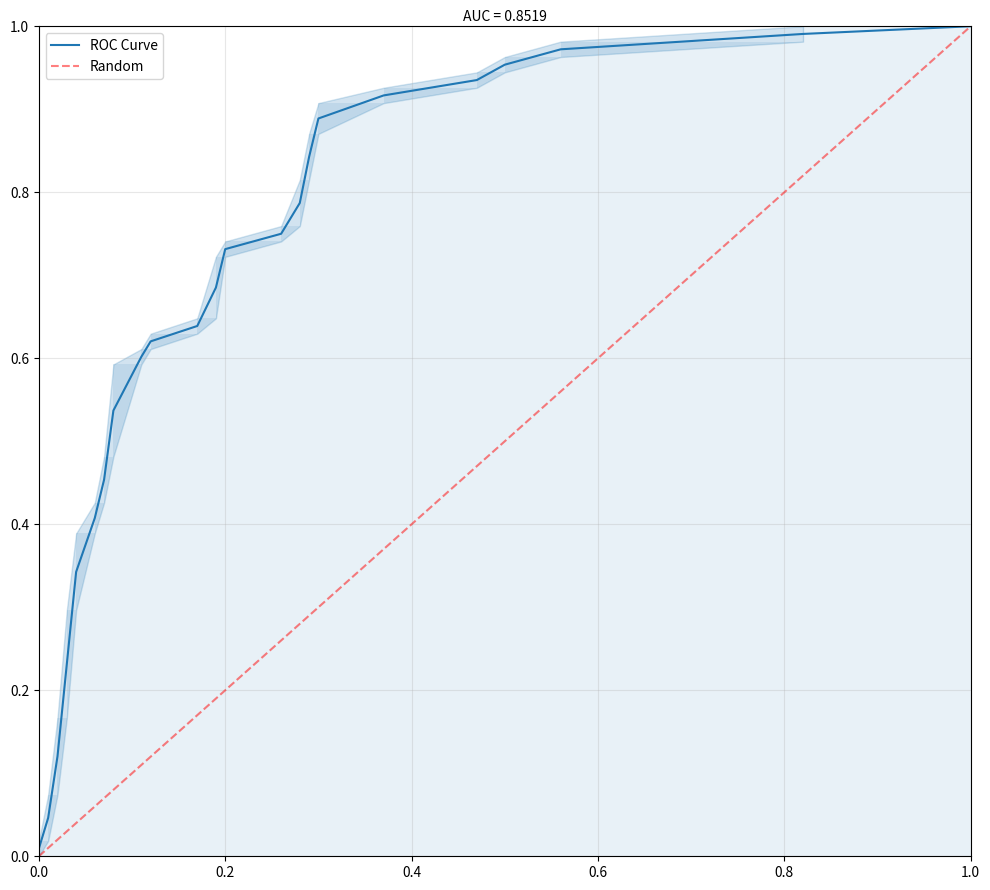

CPU times: total: 938 ms
Wall time: 2.47 s


,의사결정계수(R2),정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성률(Fallout, FPR)",특이성(TNR),F1 Score,AUC
SGDClassifier,0.293,0.773,0.694,0.630,0.150,0.850,0.660,0.852


In [18]:
%%time

# ==================================================
# 1. Pipeline 정의
# ==================================================
sgd_pipe = Pipeline(
    steps=[
        ("vif_selector", VIFSelector()),
        ("scaler", StandardScaler()),
        (
            "model",
            SGDClassifier(
                random_state=52,
                n_jobs=-1,
            ),
        ),
    ]
)


# ==================================================
# 2. 하이퍼파라미터 설정
# ==================================================
sgd_param_grid = {
    "model__loss": ["hinge", "log_loss", "modified_huber"],
    "model__penalty": ["l2", "l1", "elasticnet"],
    "model__alpha": [0.01, 0.1, 1, 10, 100],  # C의 역수 개념
    "model__max_iter": [1000, 2000, 5000],
    "model__class_weight": [None, "balanced"],
}


# ==================================================
# 3. GridSearchCV
# ==================================================
sgd_gs = GridSearchCV(
    estimator=sgd_pipe,
    param_grid=sgd_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)


# ==================================================
# 4. 모델 학습
# ==================================================
sgd_gs.fit(X_train, y_train)

sgd_estimator = sgd_gs.best_estimator_


# ==================================================
# 5. 성능 평가
# ==================================================
sgd_score_df = hs_cls_bin_scores(
    sgd_estimator,
    X_test,
    y_test,
)

sgd_score_df


### KNN

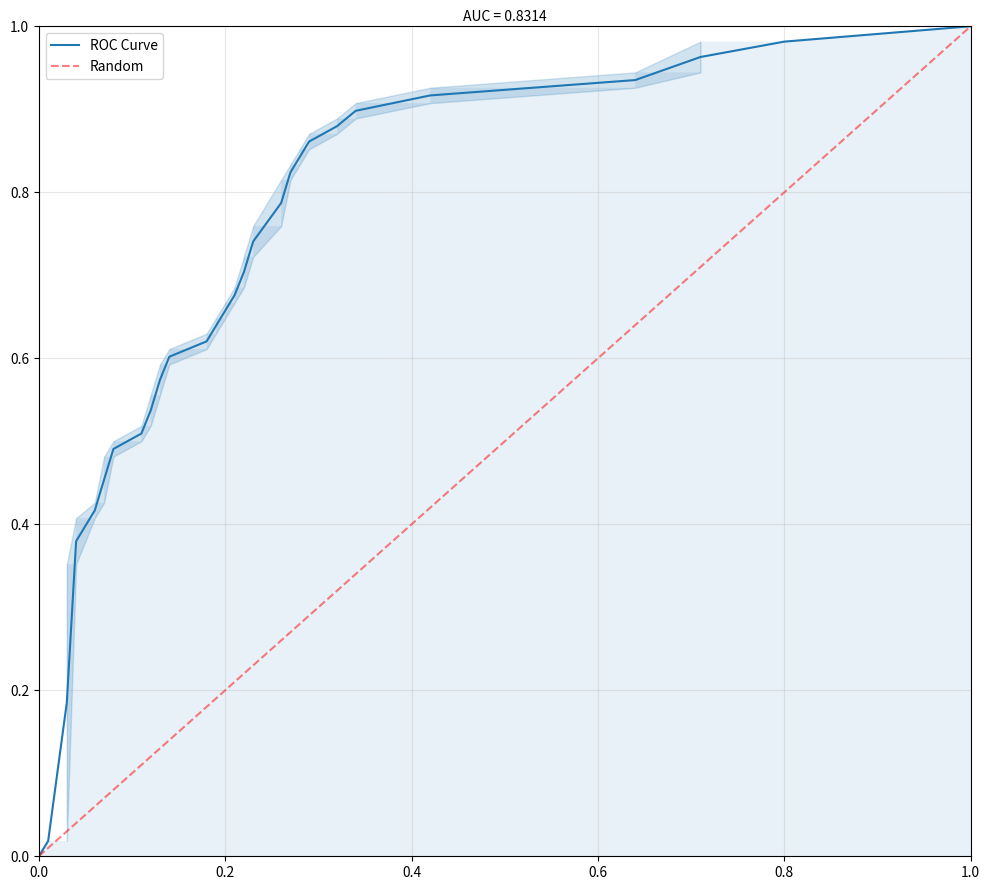

CPU times: total: 484 ms
Wall time: 1.2 s


,의사결정계수(R2),정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성률(Fallout, FPR)",특이성(TNR),F1 Score,AUC
KNeighborsClassifier,-0.425,0.747,0.642,0.630,0.190,0.810,0.636,0.831


In [19]:
%%time

# ==================================================
# 1. Pipeline 정의
# ==================================================
knn_cls_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),  # 거리기반 → 스케일링 필수
        (
            "model",
            KNeighborsClassifier(
                n_jobs=-1,
            ),
        ),
    ]
)


# ==================================================
# 2. 하이퍼파라미터 설정
# ==================================================
knn_cls_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 15, 25],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan", "minkowski"],
    "model__p": [1, 2],
}


# ==================================================
# 3. GridSearchCV
# ==================================================
knn_cls_gs = GridSearchCV(
    estimator=knn_cls_pipe,
    param_grid=knn_cls_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)


# ==================================================
# 4. 모델 학습
# ==================================================
knn_cls_gs.fit(X_train, y_train)

knn_cls_estimator = knn_cls_gs.best_estimator_


# ==================================================
# 5. 성능 평가
# ==================================================
knn_cls_score_df = hs_cls_bin_scores(
    knn_cls_estimator,
    X_test,
    y_test,
)

knn_cls_score_df


### SVM

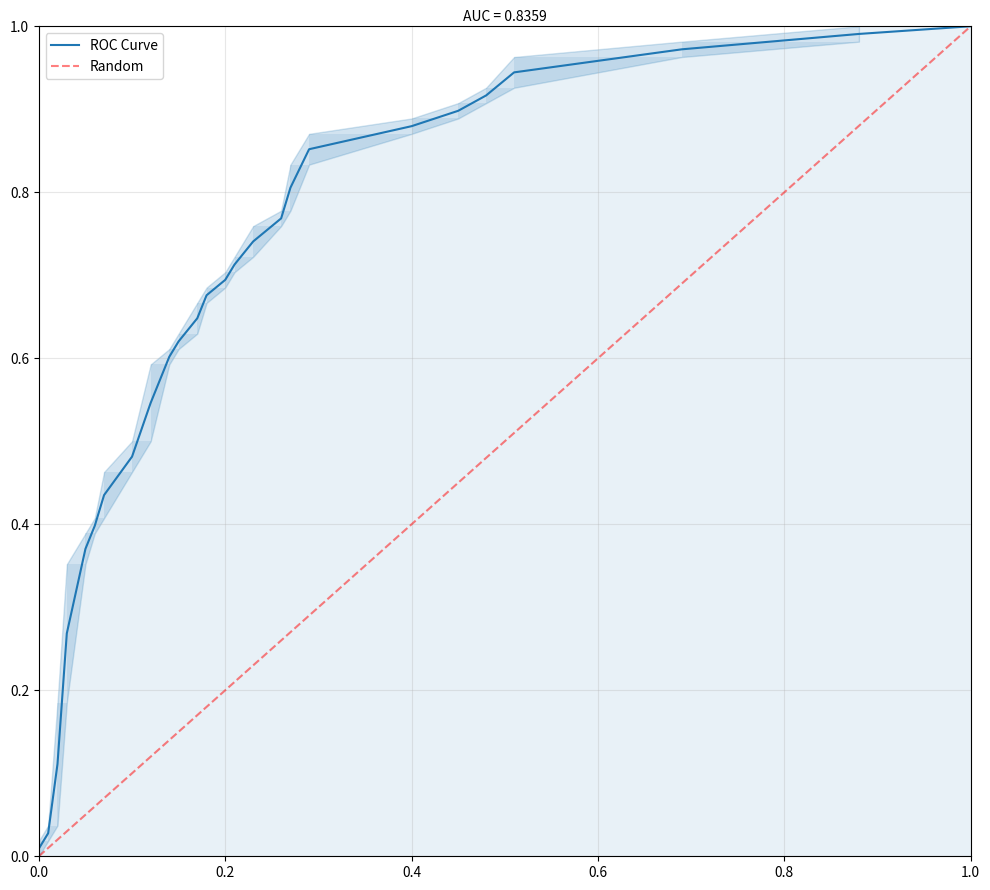

CPU times: total: 688 ms
Wall time: 5.86 s


,의사결정계수(R2),정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성률(Fallout, FPR)",특이성(TNR),F1 Score,AUC
SVC,0.269,0.753,0.608,0.833,0.290,0.710,0.703,0.836


In [36]:
%%time

# ==================================================
# 1. Pipeline 정의
# ==================================================
svc_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),  # SVM 필수
        (
            "model",
            SVC(
                random_state=52,
                cache_size=200,
                probability=True,  # ROC/AUC 계산을 위해 필수
            ),
        ),
    ]
)


# ==================================================
# 2. 하이퍼파라미터 설정
# ==================================================
svc_param_grid = {
    "model__kernel": ["rbf"],  # 기본 실험은 rbf 고정
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", "auto", 0.01, 0.1, 1],
    "model__degree": [2, 3, 4],  # kernel='poly'일 때만 의미 있음
    "model__class_weight": [None, "balanced"],
}


# ==================================================
# 3. GridSearchCV
# ==================================================
svc_gs = GridSearchCV(
    estimator=svc_pipe,
    param_grid=svc_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)


# ==================================================
# 4. 모델 학습
# ==================================================
svc_gs.fit(X_train, y_train)

svc_estimator = svc_gs.best_estimator_


# ==================================================
# 5. 성능 평가
# ==================================================
svc_score_df = hs_cls_bin_scores(
    svc_estimator,
    X_test,
    y_test,
)

svc_score_df



### XGBoost

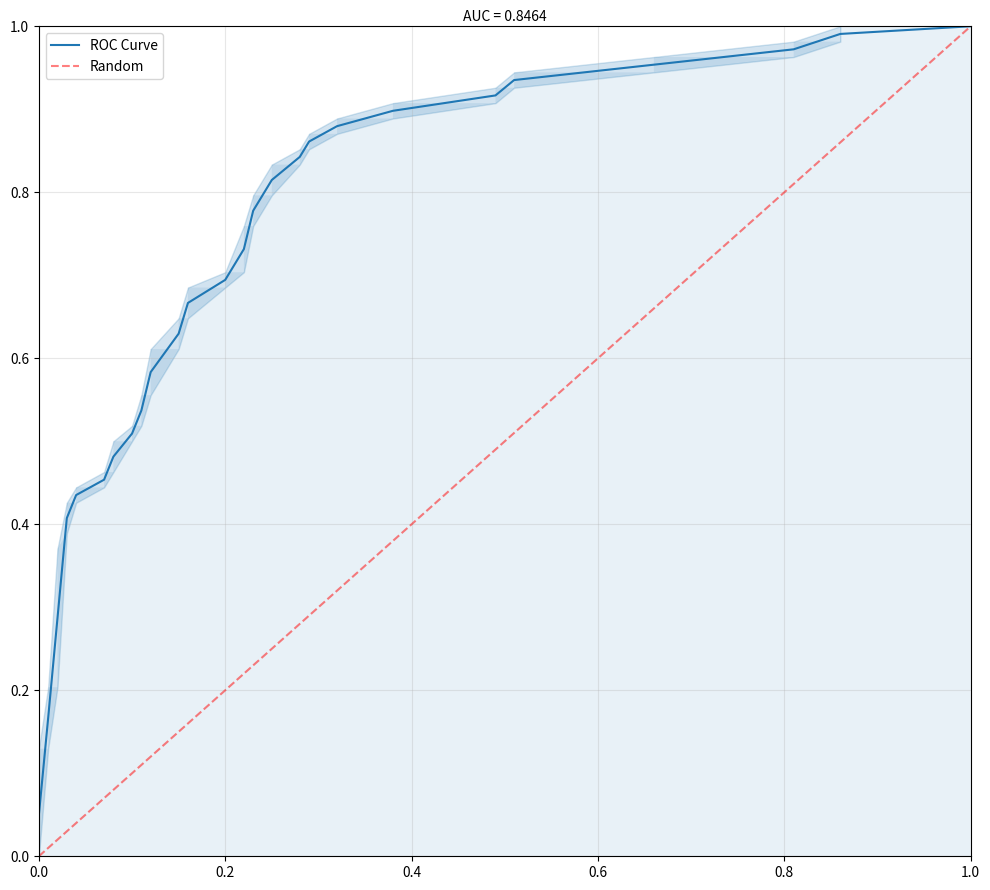

CPU times: total: 18.4 s
Wall time: 2min 11s


,의사결정계수(R2),정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성률(Fallout, FPR)",특이성(TNR),F1 Score,AUC
XGBClassifier,0.287,0.773,0.686,0.648,0.160,0.840,0.667,0.846


In [30]:
%%time

# ==================================================
# 1. Pipeline 정의
# ==================================================
xgb_cls_pipe = Pipeline(
    steps=[
        (
            "model",
            XGBClassifier(
                objective="binary:logistic",
                random_state=52,
                n_jobs=-1,
            ),
        ),
    ]
)


# ==================================================
# 2. 하이퍼파라미터 설정
# ==================================================
xgb_cls_param_grid = {
    "model__n_estimators": [100, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__min_child_weight": [1, 5, 10],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__reg_alpha": [0, 0.1, 1],
    "model__reg_lambda": [1, 5, 10],
    "model__scale_pos_weight": [1],  # 클래스 불균형 시 조정
}


# ==================================================
# 3. GridSearchCV
# ==================================================
xgb_cls_gs = GridSearchCV(
    estimator=xgb_cls_pipe,
    param_grid=xgb_cls_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)


# ==================================================
# 4. 모델 학습
# ==================================================
xgb_cls_gs.fit(X_train, y_train)

xgb_cls_estimator = xgb_cls_gs.best_estimator_


# ==================================================
# 5. 성능 평가
# ==================================================
xgb_cls_score_df = hs_cls_bin_scores(
    xgb_cls_estimator,
    X_test,
    y_test,
)

xgb_cls_score_df


### LightGBM

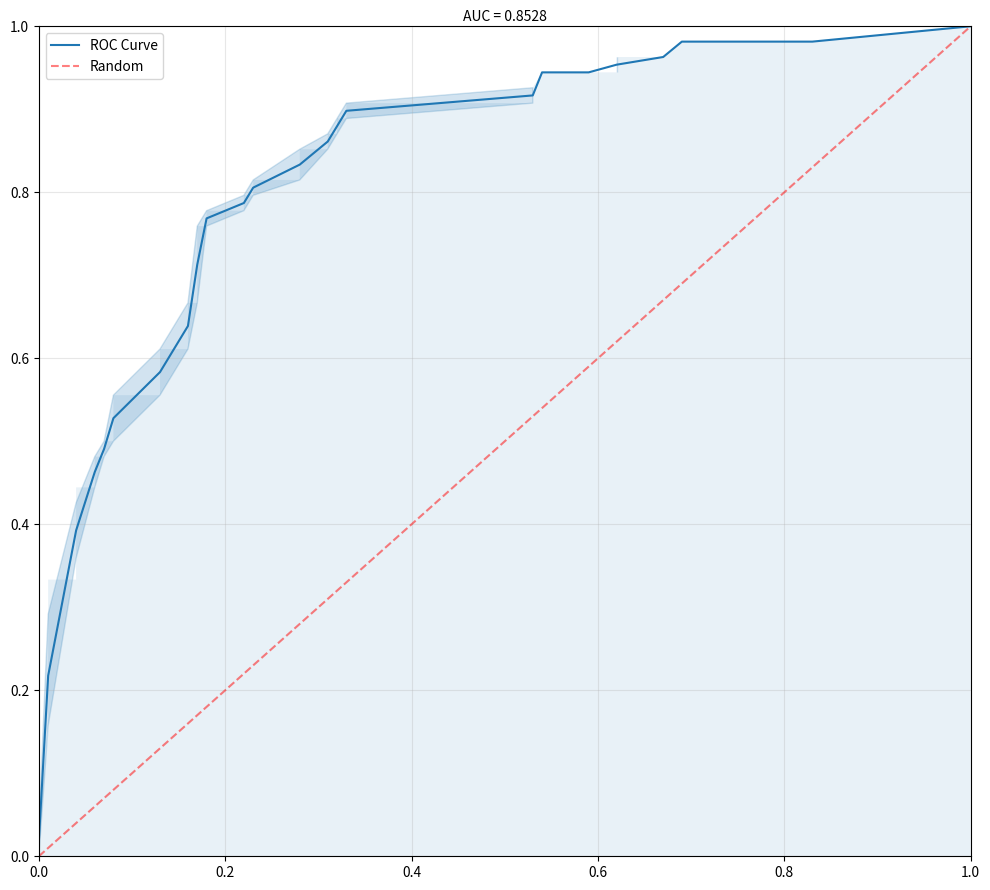

CPU times: total: 1.62 s
Wall time: 14.6 s


,의사결정계수(R2),정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성률(Fallout, FPR)",특이성(TNR),F1 Score,AUC
LGBMClassifier,0.254,0.766,0.705,0.574,0.130,0.870,0.633,0.853


In [31]:
%%time

# ==================================================
# 1. Pipeline 정의
# ==================================================
lgbm_cls_pipe = Pipeline(
    steps=[
        (
            "model",
            LGBMClassifier(
                objective="binary",
                random_state=52,
                n_jobs=-1,
                verbose=-1,
            ),
        ),
    ]
)


# ==================================================
# 2. 하이퍼파라미터 설정
# ==================================================
lgbm_cls_param_grid = {
    "model__n_estimators": [100, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],

    # 구조 관련 (필요 시 활성화)
    # "model__num_leaves": [15, 31],
    # "model__max_depth": [3, 5],
    # "model__min_child_samples": [10, 20],
    # "model__subsample": [0.6, 0.8, 1.0],

    "model__reg_alpha": [0, 0.1, 1],
    "model__reg_lambda": [0, 1, 5],
}


# ==================================================
# 3. GridSearchCV
# ==================================================
lgbm_cls_gs = GridSearchCV(
    estimator=lgbm_cls_pipe,
    param_grid=lgbm_cls_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)


# ==================================================
# 4. 모델 학습
# ==================================================
lgbm_cls_gs.fit(X_train, y_train)

lgbm_cls_estimator = lgbm_cls_gs.best_estimator_


# ==================================================
# 5. 성능 평가
# ==================================================
lgbm_cls_score_df = hs_cls_bin_scores(
    lgbm_cls_estimator,
    X_test,
    y_test,
)

lgbm_cls_score_df


### CatBoost

c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
5 fits failed out of a total of 480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\itwill\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1474, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\itwill\App

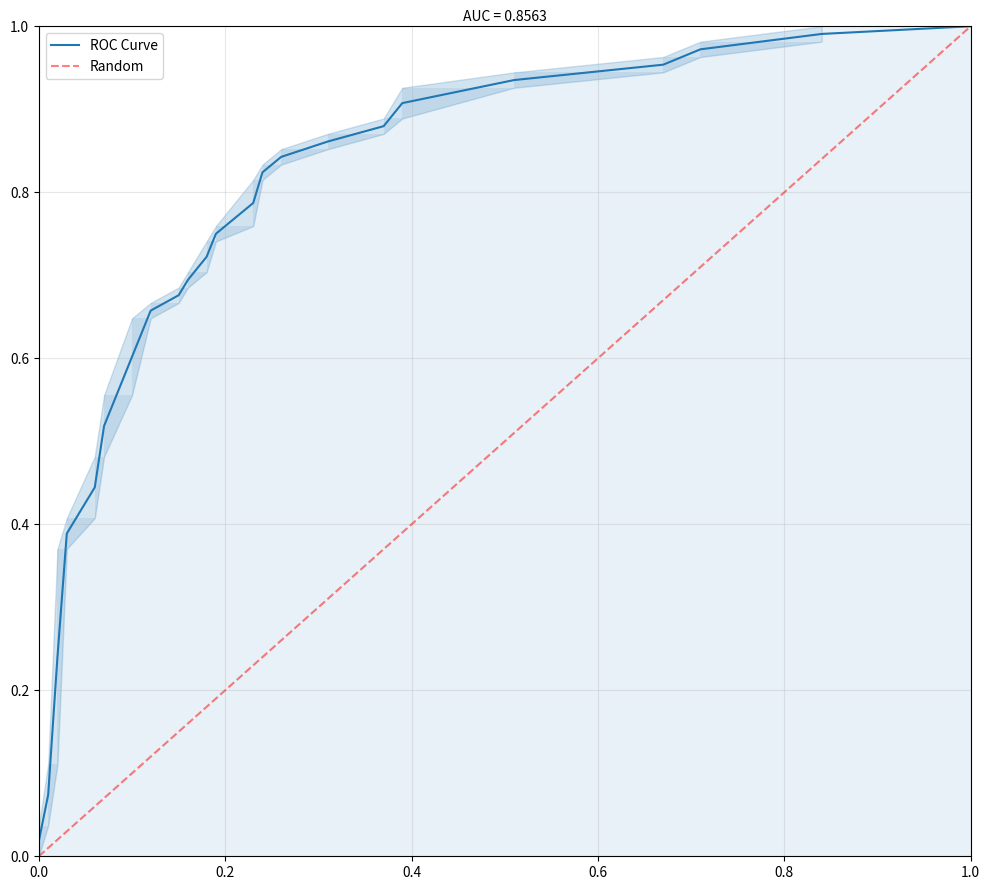

CPU times: total: 5.12 s
Wall time: 1min 18s


,의사결정계수(R2),정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성률(Fallout, FPR)",특이성(TNR),F1 Score,AUC
CatBoostClassifier,0.305,0.805,0.761,0.648,0.110,0.890,0.700,0.856


In [32]:
%%time

# ==================================================
# 1. Pipeline 정의
# ==================================================
cat_cls_pipe = Pipeline(
    steps=[
        (
            "model",
            CatBoostClassifier(
                loss_function="Logloss",
                eval_metric="AUC",
                cat_features=[],          # 범주형 컬럼 인덱스 지정 가능
                random_state=52,
                thread_count=-1,
                verbose=0,
            ),
        ),
    ]
)


# ==================================================
# 2. 하이퍼파라미터 설정
# ==================================================
cat_cls_param_grid = [

    # --------------------------------------------------
    # Case 1: Bayesian bootstrap
    # --------------------------------------------------
    {
        "model__bootstrap_type": ["Bayesian"],
        "model__iterations": [300, 500],
        "model__learning_rate": [0.01, 0.03],
        "model__depth": [4, 6],
        "model__l2_leaf_reg": [1, 3],
        "model__rsm": [0.6, 1.0],
    },

    # --------------------------------------------------
    # Case 2: Bernoulli bootstrap
    # --------------------------------------------------
    {
        "model__bootstrap_type": ["Bernoulli"],
        "model__iterations": [300, 500],
        "model__learning_rate": [0.01, 0.03],
        "model__depth": [4, 6],
        "model__l2_leaf_reg": [1, 3],
        "model__subsample": [0.6, 1.0],
        "model__rsm": [0.6, 1.0],
    },
]


# ==================================================
# 3. GridSearchCV
# ==================================================
cat_cls_gs = GridSearchCV(
    estimator=cat_cls_pipe,
    param_grid=cat_cls_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)


# ==================================================
# 4. 모델 학습
# ==================================================
cat_cls_gs.fit(X_train, y_train)

cat_cls_estimator = cat_cls_gs.best_estimator_


# ==================================================
# 5. 성능 평가
# ==================================================
cat_cls_score_df = hs_cls_bin_scores(
    cat_cls_estimator,
    X_test,
    y_test,
)

cat_cls_score_df


# 결과 정리<br>
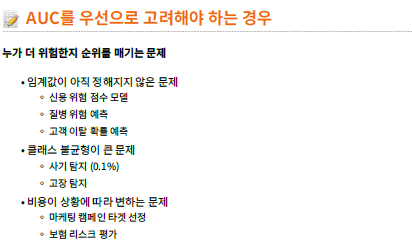


In [77]:
result_df = concat([logit_score_df, sgd_score_df, knn_cls_score_df, svc_score_df, rf_cls_score_df, xgb_cls_score_df, lgbm_cls_score_df, cat_cls_score_df])

result_df.sort_values('AUC', ascending=False, inplace=True)

result_df

,의사결정계수(R2),정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성률(Fallout, FPR)",특이성(TNR),F1 Score,AUC
RandomForestClassifier,0.278,0.747,0.609,0.778,0.270,0.730,0.683,0.859
CatBoostClassifier,0.305,0.805,0.761,0.648,0.110,0.890,0.700,0.856
LogisticRegression,0.226,0.766,0.629,0.815,0.260,0.740,0.710,0.854
LGBMClassifier,0.254,0.766,0.705,0.574,0.130,0.870,0.633,0.853
SGDClassifier,0.293,0.773,0.694,0.630,0.150,0.850,0.660,0.852
XGBClassifier,0.287,0.773,0.686,0.648,0.160,0.840,0.667,0.846
SVC,0.269,0.753,0.608,0.833,0.290,0.710,0.703,0.836
KNeighborsClassifier,-0.425,0.747,0.642,0.630,0.190,0.810,0.636,0.831


### recall을 우선 고려해야 하는 경우

In [79]:
result_df.sort_values('재현율(Recall, TPR)', ascending=False)

,의사결정계수(R2),정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성률(Fallout, FPR)",특이성(TNR),F1 Score,AUC
SVC,0.269,0.753,0.608,0.833,0.290,0.710,0.703,0.836
LogisticRegression,0.226,0.766,0.629,0.815,0.260,0.740,0.710,0.854
RandomForestClassifier,0.278,0.747,0.609,0.778,0.270,0.730,0.683,0.859
CatBoostClassifier,0.305,0.805,0.761,0.648,0.110,0.890,0.700,0.856
XGBClassifier,0.287,0.773,0.686,0.648,0.160,0.840,0.667,0.846
SGDClassifier,0.293,0.773,0.694,0.630,0.150,0.850,0.660,0.852
KNeighborsClassifier,-0.425,0.747,0.642,0.630,0.190,0.810,0.636,0.831
LGBMClassifier,0.254,0.766,0.705,0.574,0.130,0.870,0.633,0.853
